# D5 — A Kelvin wave grows and decays

An exact two-dimensional wave on the unbounded affine background U=(S*y,0). This is a dimensionless reduced example, not the OpenAI pulse or a finite-energy whole-space solution.

In [1]:
import json
import numpy as np
from IPython.display import display, Image
from nscomp.shear import KelvinWave, integrate_amplitude
from nscomp.d5 import STUDY, WRITING, load_parameters, generate
p=load_parameters()
wave=KelvinWave(**p['wave'])
times=np.linspace(0,p['time']['end'],p['time']['samples'])
state=wave.state(times)
print('Initial amplitude:', state['velocity_amplitude'][0])
print('Initial speed:', state['speed'][0])

Initial amplitude: [-0.9701425   0.24253563]
Initial speed: 1.0


## Wavevector, velocity, and wavelength

The wavevector changes through ky=ky0-S*kx*t. Vorticity is damped by exp(-nu*integral |k|² dt), while velocity also has the factor 1/|k|. Our normal wavelength uses laboratory coordinates.

In [2]:
for t in (0,4,12,20):
    s=wave.state(t)
    print(f't={t:2}: ky={s["ky"]:6.2f}, speed={s["speed"]:.6g}, wavelength={s["wavelength"]:.6g}')

t= 0: ky=  4.00, speed=1, wavelength=1.5239
t= 4: ky=  0.00, speed=3.63257, wavelength=6.28319
t=12: ky= -8.00, speed=0.184411, wavelength=0.779333
t=20: ky=-16.00, speed=0.00022684, wavelength=0.391934


## Energy transfer and stress

Use phase averages: E=|B|²/4, Qxy=Bx*By/2. The perturbation energy equation is dE/dt=-S*Qxy-2*nu*|k|²*E. The background has no finite whole-space energy.

In [3]:
from scipy.integrate import simpson
budget=simpson(state['energy_rate'], x=times)
change=state['energy'][-1]-state['energy'][0]
print('Integrated production minus dissipation:', budget)
print('Actual energy change:', change)
print('Energy-budget quadrature error:', abs(budget-change))

Integrated production minus dissipation: -0.24999998713947902
Actual energy change: -0.24999998713587965
Energy-budget quadrature error: 3.599370801410373e-12


## Independent time integration

RK4 advances the pressure-projected momentum equation, not the closed-form vorticity solution. No projection is applied to hide the computed incompressibility error.

In [4]:
for step in p['refinement_steps']:
    t, B=integrate_amplitude(wave,p['time']['end'],step)
    exact=wave.state(t)
    error=np.max(np.linalg.norm(B-exact['velocity_amplitude'],axis=1))
    constraint=np.max(abs(wave.kx*B[:,0]+exact['ky']*B[:,1]))
    print(f'dt={step:.3f}: amplitude error={error:.3g}, constraint defect={constraint:.3g}')

dt=0.400: amplitude error=0.00108, constraint defect=1.59e-05
dt=0.200: amplitude error=6.28e-05, constraint defect=1.01e-06
dt=0.100: amplitude error=3.63e-06, constraint defect=6.45e-08
dt=0.050: amplitude error=2.16e-07, constraint defect=4.08e-09
dt=0.025: amplitude error=1.32e-08, constraint defect=2.56e-10


## Regenerate the study

Four CSV files provide time histories, refinement diagnostics, snapshot parameters, and phase profiles. The snapshots show a window into the unbounded solution; their top and bottom are not periodic walls.

In [5]:
summary=generate()
print(json.dumps(summary,indent=2))

{
  "peak_time": 3.9949997622309743,
  "peak_speed_ratio": 3.6326140232901247,
  "peak_energy_ratio": 13.195884642204067,
  "turn_time": 4.0,
  "shortest_wavelength": 0.3919343310572741,
  "longest_wavelength": 6.283185307179586,
  "final_speed_ratio": 0.0002268402112030213,
  "final_vorticity_ratio": 0.0008819869188235046,
  "time_sample_spacing": 0.01,
  "finest_rk4_amplitude_error": 1.3199634199207448e-08,
  "finest_rk4_constraint_defect": 2.5642754586385763e-10,
  "refinement_error_ratios": [
    17.147823490099483,
    17.31187414920577,
    16.760825401248624,
    16.393254457589567
  ],
  "integrated_energy_budget_error": 3.599370801410373e-12,
  "snapshot_minimum_axis_samples_per_wavelength": 32.0,
  "paper_pulse_reconstructed": false,
  "parameters_sha256": "3411cfd55ff8d88d9aa0e903b04e81687ee460b8a4da019995a8c1fe3407d747"
}


## Figures and limitations

The three figures share one baseline. Vorticity colors use the initial amplitude in every snapshot. The complete rotating pulse, localization, seed force, and stress matching are outside this example.

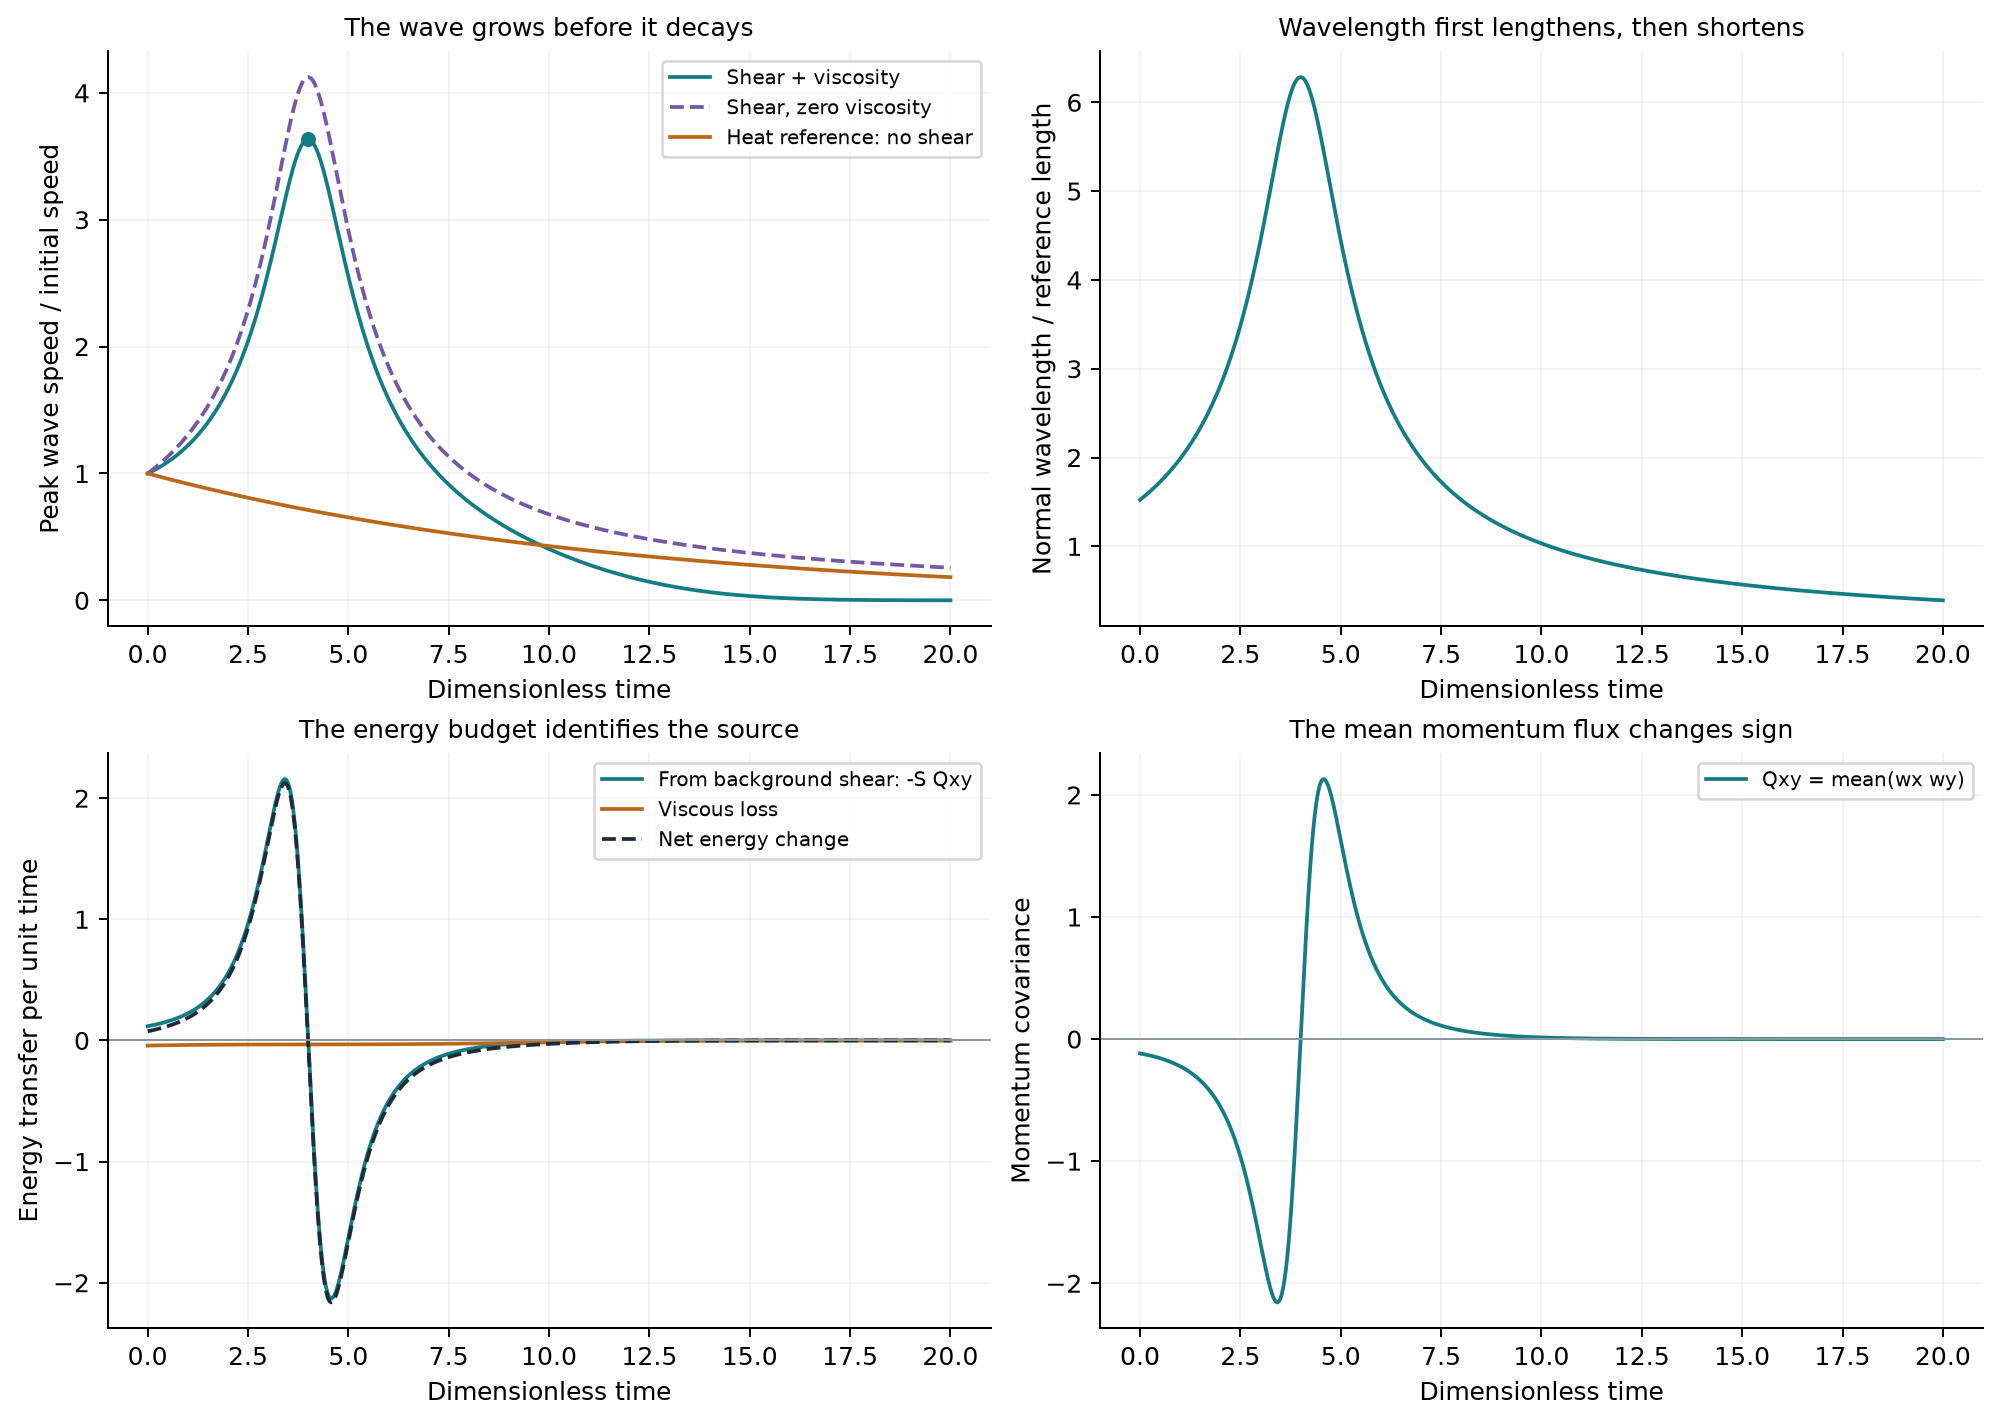

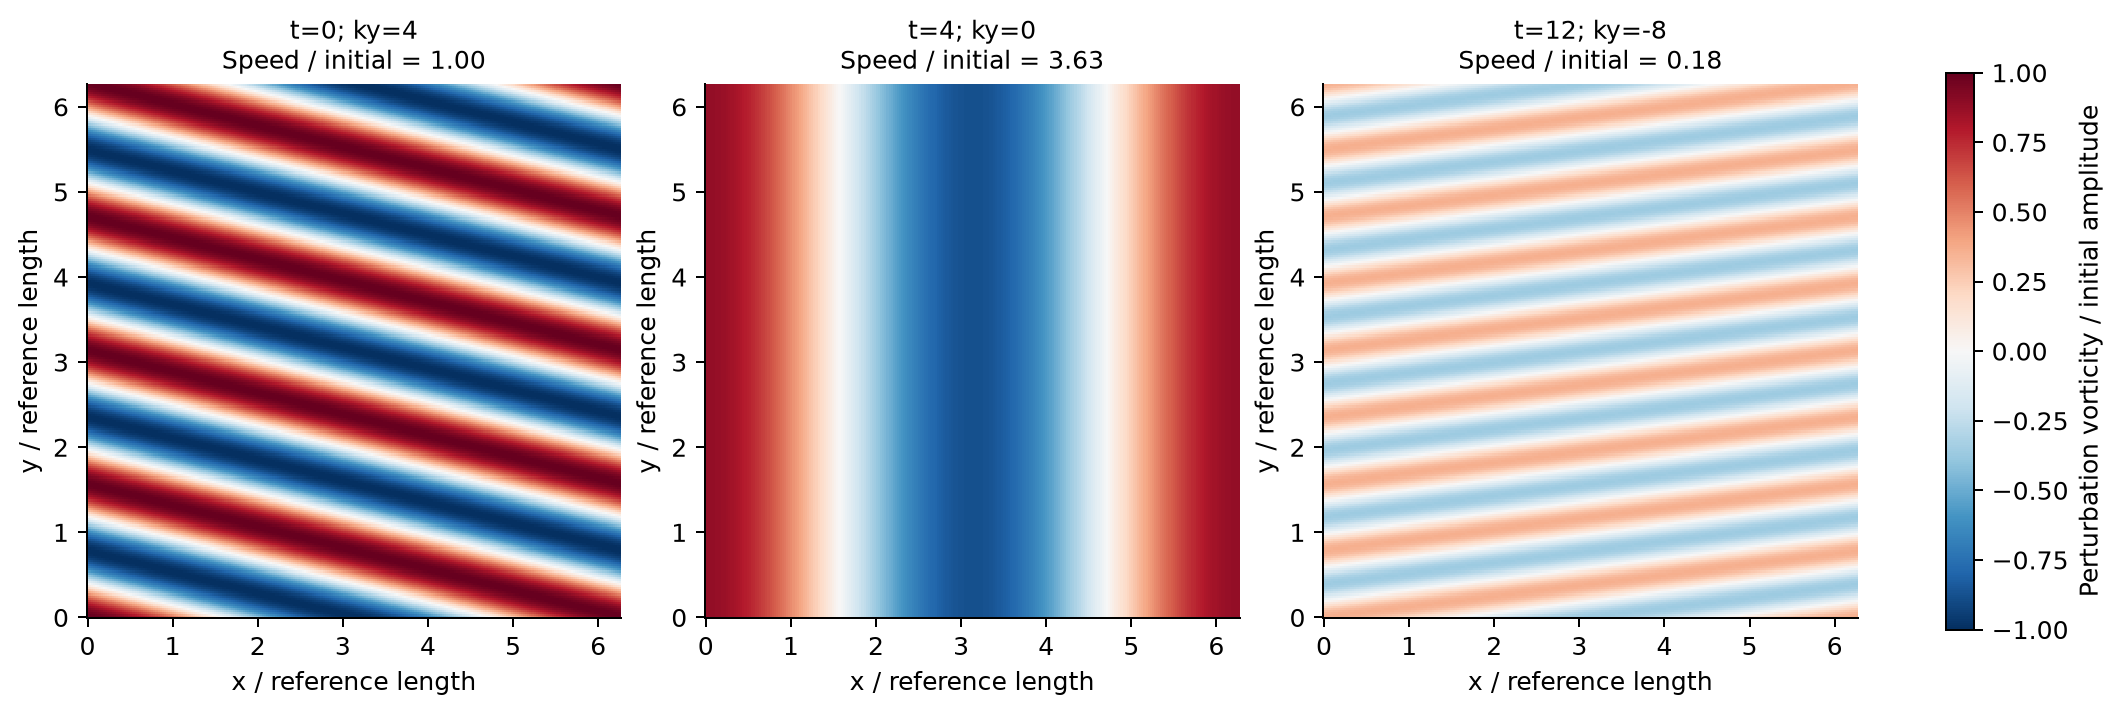

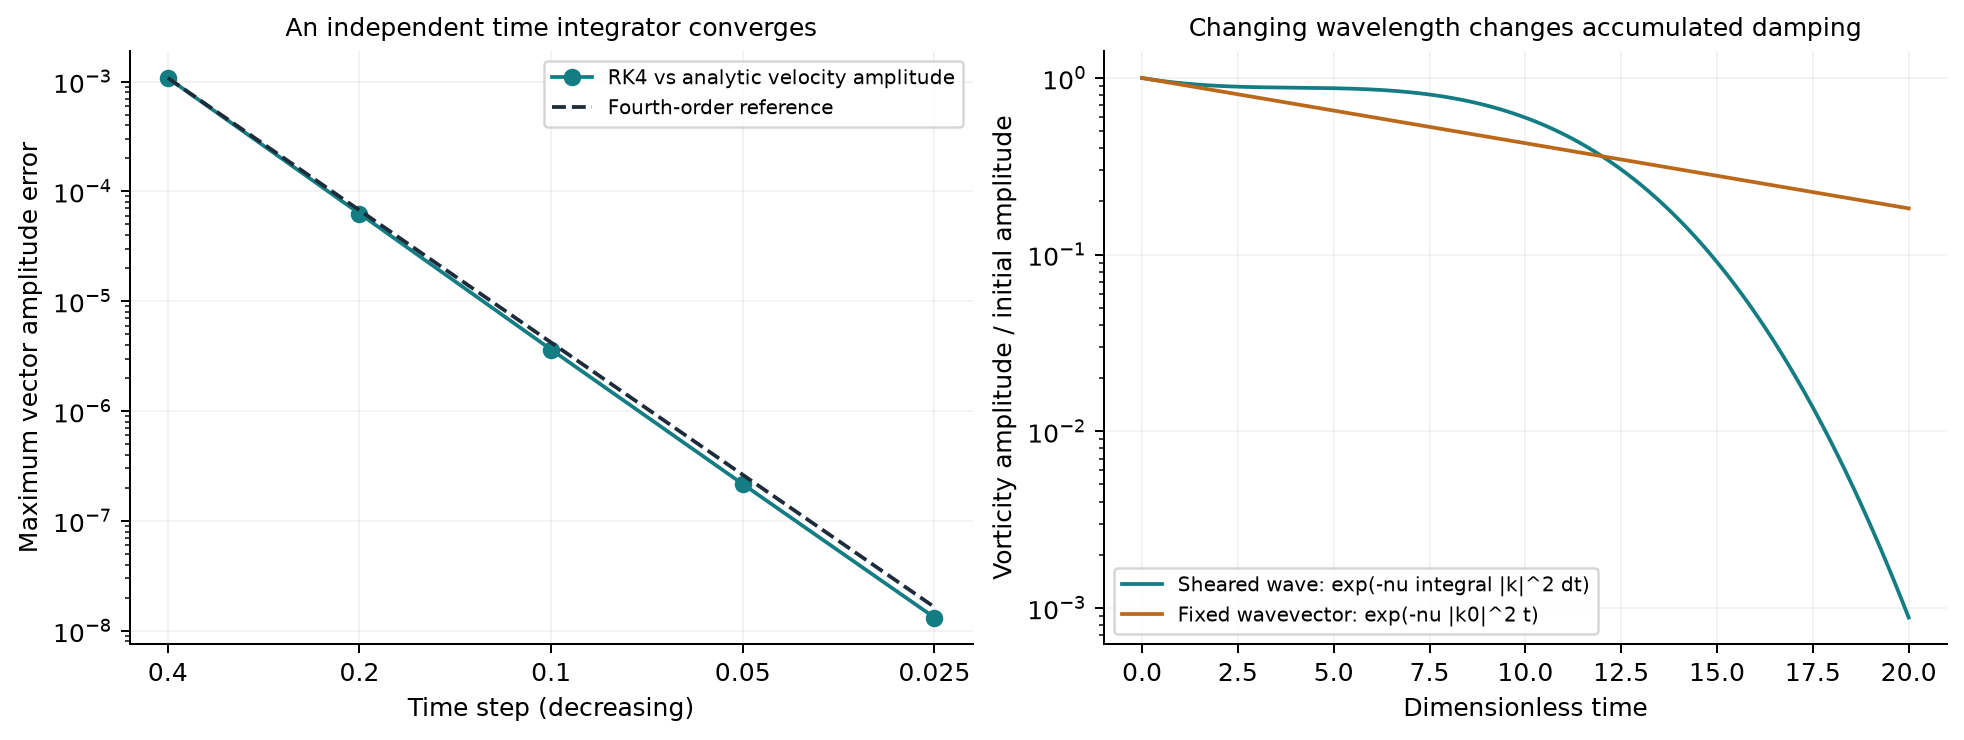

In [6]:
for name in ('01_wave_lifecycle','02_wave_orientation','03_time_accuracy_and_damping'):
    display(Image(filename=str(WRITING/'figures'/f'{name}.png')))